# Quantitative analysis of coherence-induced imaging artefacts

This notebook contains the analysis used to quantify the suppression of coherence-induced imaging artefacts presented in the supplementary material accompanying the manuscript 

*<div align ="center"> Absorption imaging of quantum gases near surfaces using incoherent light. </div>*

The analysis compares images acquired at different degrees of spatial coherence using two complementary measures:

1. the Fourier power contained within the spatial-frequency range associated with the observed fringe structure; and
2. the band-limited RMS fringe contrast.

The workflow consists of image preprocessing, background normalisation, Tukey windowing, Fourier analysis, spatial-frequency calibration, integrated Fourier-power calculation, and RMS-contrast calculation.


## 1. Import required packages

Here we import the relavant packages for this analysis

In [1]:
import os                                                                                           # locating, organising, and accessing the image files used in the analysis.
from pathlib import Path                                                                            # locating, organising, and accessing the image files used in the analysis.

import numpy as np                                                                                  # numerical array handling and mathematical operations.
import pandas as pd                                                                                 # organising calculated quantities and analysis results into structured datasets.
import scipy as sp                                                                                  # scientific computing and signal-processing routines.
import matplotlib.pyplot as plt                                                                     # Plotting and visualization package.
from matplotlib.ticker import AutoMinorLocator, MaxNLocator,LogLocator, NullFormatter               # ontrolling major, minor, linear, and logarithmic axis ticks for publication-quality figures.

from PIL import Image                                                                               # image file handling and manipulation.
from scipy.ndimage import gaussian_filter                                                           # generating the slowly varying background used to normalise each image.
from scipy.signal.windows import tukey                                                              # For generating a smoothly varying window function to reduce edge effects in the Fourier transform.
from scipy.signal import find_peaks                                                                 # For detecting peaks in the integrated intensity profile. 

In [2]:
# This cell is for plot formatting

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,

    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

TEXTWIDTH = 6.8

Found 6 image files in C:\Users\Poppy\Desktop\PhD\Papers\IncoherentImaging\ReviwersResponse\IncoherentImagingManuscript\RawImages


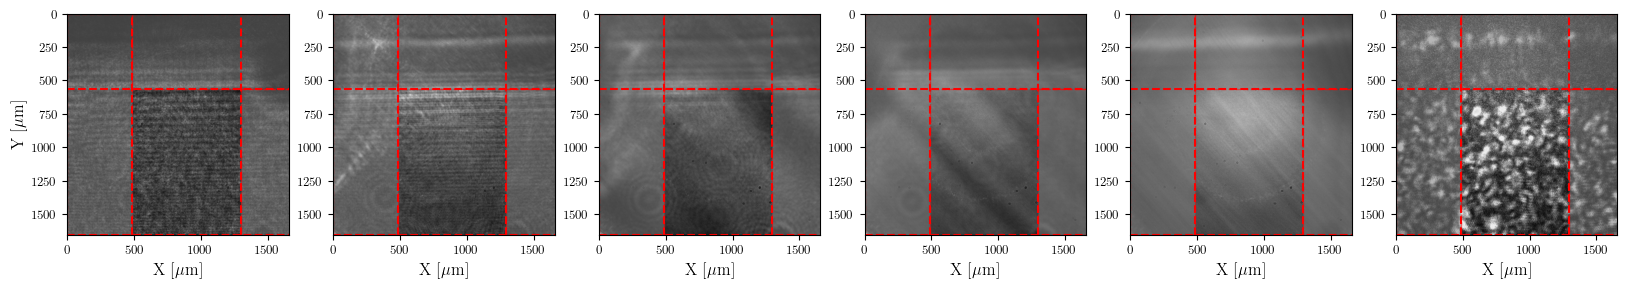

In [3]:
data_dir = Path("C:\\Users\\Poppy\\Desktop\\PhD\\Papers\\IncoherentImaging\\ReviwersResponse\\IncoherentImagingManuscript\\RawImages")        #Define data path

ImgFiles = sorted(data_dir.glob("*.png"))                                                           #Define image files to be analyzed
print(f"Found {len(ImgFiles)} image files in {data_dir}")                                           # Checks we have found all the files

Imgs = [Image.open(img_file) for img_file in ImgFiles]                                              # Open images and store them in a list

Mag = 8.025                                                                                         # magnification          
PxSz = 13                                                                                           # [um] pixel size of Andor iXon Ultra 888 EMCCD camera

#All images have the same dims. Convert pixel coordinates to micrometers using the pixel size and magnification size[1] = Y, size[0] = X
y_um = np.arange(0, Imgs[0].size[1]) * PxSz / Mag                                                   # y-axis in micrometers
x_um = np.arange(0, Imgs[0].size[0]) * PxSz / Mag                                                   # x-axis in micrometers

cropPx = np.array([300, 800, 350, len(y_um)], dtype=int)
crop_um = cropPx * PxSz / Mag

fig,ax = plt.subplots(1,len(Imgs),figsize=(20,50))                                                  # Create a figure and axes
for i in range(len(Imgs)):
    img = np.array(Imgs[i])                                                                         # Convert image to numpy array         
    ax[i].imshow(img, extent = [x_um[0], x_um[-1], y_um[-1], y_um[0]], cmap="gray")                 # plotting the images                                                          
    ax[i].set_xlabel('X [$\mu$m]')
    ax[0].set_ylabel('Y [$\mu$m]')
    ax[i].axvline(crop_um[0] , color='r', linestyle='--')                                         # Defining lower left limit
    ax[i].axvline(crop_um[1] , color='r', linestyle='--')                                         # Defining far right limit
    ax[i].axhline(crop_um[2] , color='r', linestyle='--')                                         # Defining upper Y limit
    ax[i].axhline(crop_um[3] , color='r', linestyle='--')                                         # Defining bottom Y limit
    ax[i].add_patch(plt.Rectangle((0, 0), crop_um[0], crop_um[3], edgecolor='r', facecolor='gray', linestyle='--',alpha=0.5)) # Defining right shaded region
    ax[i].add_patch(plt.Rectangle((crop_um[0], y_um[0]),crop_um[1], crop_um[2]-y_um[0], edgecolor='r', facecolor='gray', linestyle='--',alpha=0.5)) # Defining the top shaded region
    ax[i].add_patch(plt.Rectangle((crop_um[1], crop_um[2]), crop_um[1], crop_um[3]-crop_um[2], edgecolor='r', facecolor='gray', linestyle='--',alpha=0.5)) # Defining the right shaded region
    ax[i].set_ylim(y_um[-1], y_um[0])
plt.show()                                                                                          # showing the figure



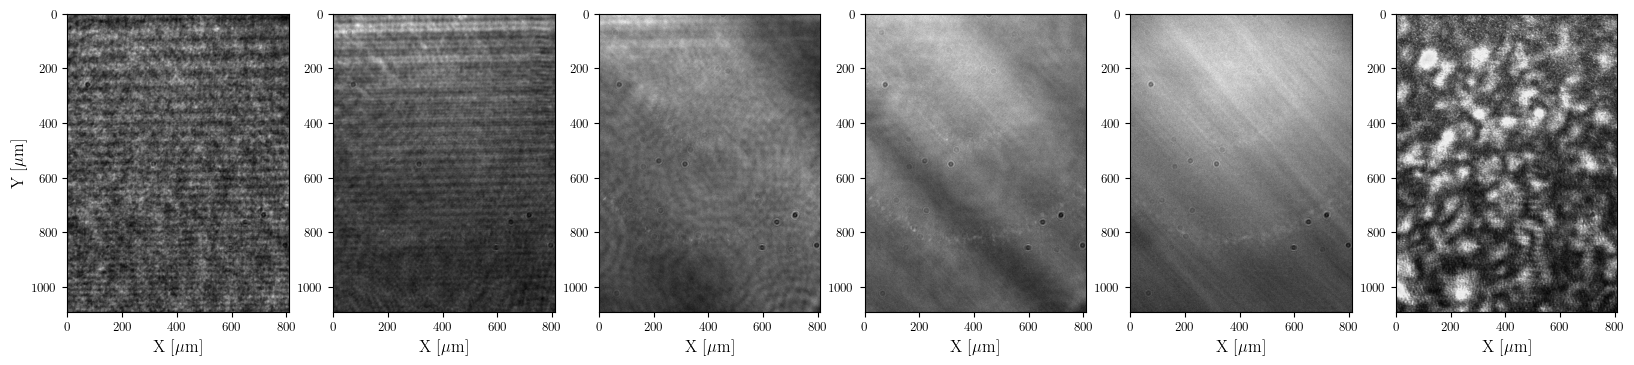

In [4]:
fig, ax = plt.subplots(1, len(Imgs), figsize=(20, 5))                                               #setting figure size
ImagesList = []                                                                                     # Saving cropped images


for i in range(len(Imgs)):

    img = np.array(Imgs[i])                                                                         # Convert image to numpy array  

    # Crop in pixel indices
    img_crop = img[cropPx[2]:cropPx[3], cropPx[0]:cropPx[1]]                                        # cropping the image

    ImagesList.append(img_crop)

    ax[i].imshow(
        img_crop,
        extent=[
            crop_um[0]-crop_um[0],                                                                  #plotting in microns
            crop_um[1] - crop_um[0],
            crop_um[3] - crop_um[2],
            0
        ],
        cmap="gray"
    )

    ax[i].set_xlabel(r'X [$\mu$m]')

ax[0].set_ylabel(r'Y [$\mu$m]')

plt.show()






## 2. Background filtering

A slowly varying background is estimated using a Gaussian filter with $\sigma = 100$ pixels. This removes the higher-spatial-frequency structure associated with the imaging artefacts while retaining the overall illumination profile.

The cropped image is then normalised according to

$$
I_{\mathrm{norm}}(x,y)
=
\frac{I(x,y)-I_{\mathrm{bg}}(x,y)}
{I_{\mathrm{bg}}(x,y)},
$$

where $I(x,y)$ is the measured image and $I_{\mathrm{bg}}(x,y)$ is the Gaussian-filtered background. The resulting image therefore represents the fractional intensity variation relative to the local background.



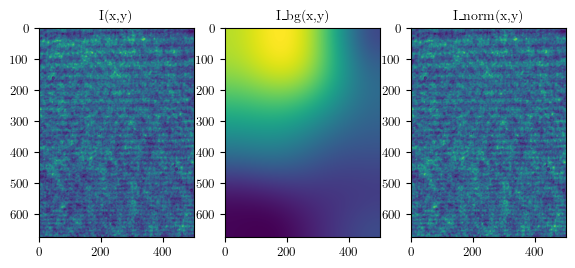

Processed images: 6


In [5]:
sigma_bg = 100                                                                                      # Gaussian width [px]      

Images = np.array(ImagesList, dtype = float)                                                        # Numpy array of cropped images as float                                                               

ImgCo = Images[0,:,:]                                                                               # Using img[0] as a test (I)

background = gaussian_filter(ImgCo, sigma=sigma_bg)                                                 # Apply Gaussian filter to estimate background (I_bg)

processed_img = (ImgCo - background) / np.clip(background, 1e-12, None)                             # Normalize image by background (I_norm)


fig, ax = plt.subplots(1, 3, figsize=(TEXTWIDTH, 5))
ax[0].imshow(ImgCo, cmap='viridis')
ax[0].set_title('I(x,y)')
ax[1].imshow(background, cmap='viridis')
ax[1].set_title('I_{bg}(x,y)')
ax[2].imshow(processed_img, cmap='viridis')
ax[2].set_title('I_{norm}(x,y)')
plt.show()

Normalised_images = []                                                                              # List to store processed images
background = []                                                                                     # List to store background images

for i in range(Images.shape[0]):
    ImgCo = Images[i,:,:]                                                                           # itterating through the Images
    background_img = gaussian_filter(ImgCo, sigma=sigma_bg)                                         # Apply Gaussian filter to estimate background (I_bg)
    processed_img = (ImgCo - background_img) / np.clip(background_img, 1e-12, None)                 # Normalize image by background (I_norm)
    Normalised_images.append(processed_img)                                                         # Store processed image
    background.append(background_img)                                                               # store background image

print("Processed images:", len(Normalised_images))

## 3. Tukey windowing

Before calculating the Fourier transform, a two-dimensional Tukey window with $\alpha = 0.1$ is applied to each processed image.

The Tukey window smoothly reduces the image amplitude towards the boundaries, suppressing artificial high-spatial-frequency components introduced by the sharp discontinuity at the image edges.

The two-dimensional window is constructed from the outer product of independent one-dimensional Tukey windows applied along the horizontal and vertical image axes.

In [6]:
alpha = 0.1                                                                                         # Selecting the alpha value

windowedImgs = []                                                                                    # empty array for storing the windowed images 

for i in range(len(Normalised_images)):
    ny, nx = Normalised_images[i].shape                                                             # Get the dimensions of the current image

    window_y = tukey(ny, alpha=alpha)                                                               # Create a 1D Tukey window for the y-dimension
    window_x = tukey(nx, alpha=alpha)                                                               # Create a 1D Tukey window for the x-dimension

    window_2d = np.outer(window_y, window_x)

    windowedImgs.append(Normalised_images[i] * window_2d)                                            # Store the windowed image in the list

windowedImgs = np.array(windowedImgs)                                                                 # Convert the list of windowed images to a NumPy array

print(windowedImgs.shape)


(6, 674, 500)


## 4. Fourier transform

The two-dimensional discrete Fourier transform is calculated for each Tukey-windowed image to identify the spatial frequencies associated with the observed fringe structure.

For each image, the zero-frequency component is shifted to the centre of the Fourier spectrum and the Fourier power is calculated as

$$
P(f_x,f_y)
=
\left|
\tilde{I}(f_x,f_y)
\right|^2,
$$

where $\tilde{I}(f_x,f_y)$ is the two-dimensional Fourier transform of the windowed image.

The Fourier-space axes are then calibrated using the object-plane pixel size so that the spectra can be expressed in physical spatial-frequency units of cycles per micrometre.

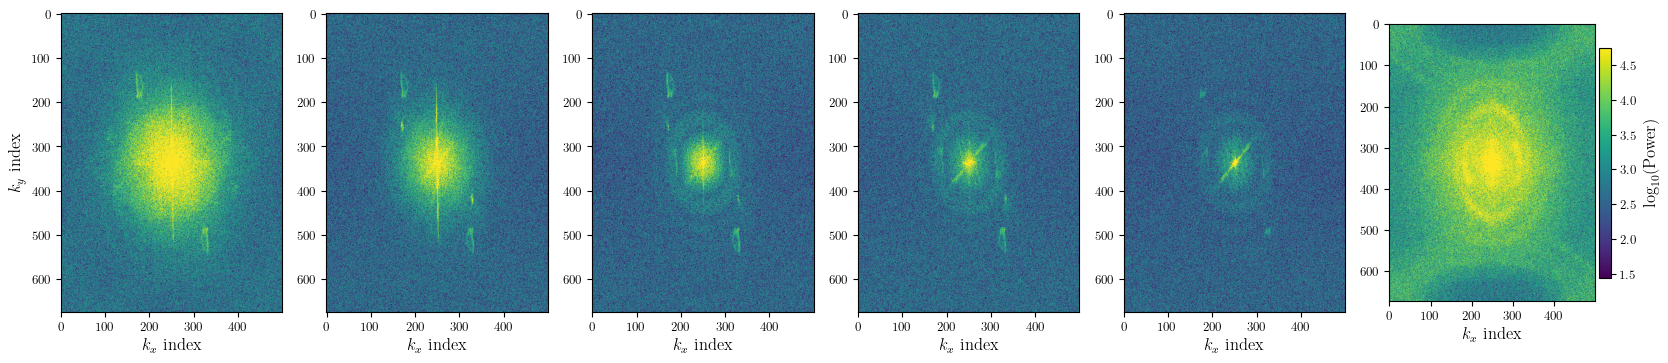

In [7]:

dy = PxSz/Mag # Object plane pixel size in the y-direction

fftPower = []                                                                                       # Empty list to store the fft power data


# Processing the all the data using the Turkey windowing method for all the processed images
for i in range(len(windowedImgs)):
    fft = np.fft.fft2(windowedImgs[i])                                                              # Compute the 2D FFT of the windowed image
    fftShift = np.fft.fftshift(fft)                                                                 # Shift the zero frequency component to the center of the spectrum
    fftPower.append(np.abs(fftShift)**2)                                                            # Compute the power spectrum of

logPowers = [np.log10(power + 1e-12) for power in fftPower]                                         # Compute the log power spectrum to avoid log(0)

vmin = min(np.percentile(lp,5) for lp in logPowers)                                                 # Minimum value for color scale based on 5th percentile
vmax = max(np.percentile(lp,95) for lp in logPowers)                                                # maximum value for color scale based on 95th percentile


fig,ax = plt.subplots(1,len(fftPower),figsize=(20,4))                                               # Create a figure and axes for the FFT power spectra
ax[0].set_ylabel(r"$k_y$ index")

for ax, logPower, windowedImg in zip(ax, logPowers, windowedImgs):                                  # Loop through the axes and log power spectra
    im = ax.imshow(logPower, vmin=vmin, vmax=vmax)         
    ax.set_xlabel(r"$k_x$ index")
    


fig.colorbar(im, ax=ax, fraction=0.052, pad=0.02, label=r"$\log_{10}(\mathrm{Power})$")             # Shared colorbar that scales to the full image row.
plt.show()

fftPower = np.array(fftPower)

## 5. One-dimensional Fourier-power spectrum

To obtain a one-dimensional measure of the fringe spatial-frequency content, the two-dimensional Fourier power spectrum is integrated along the horizontal Fourier axis, $f_x$.

This produces a one-dimensional power spectrum as a function of the vertical spatial frequency, $f_y$, which is used to characterise the spatial frequency of the coherence-induced fringes.

Because the Fourier transform of a real-valued image is symmetric about zero spatial frequency, only the positive-$f_y$ half of the spectrum is retained for further analysis.

In [8]:
dy = PxSz / Mag                                                                                     # Object plane pixel size in the y-direction

ny = fftPower.shape[1]                                                                              # Number of pixels along the y-direction

midpoint = ny // 2                                                                                  # Define the midpoint of the y-direction

fy_positive = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))[midpoint:]                                  # Positive fy frequencies

power_1D = np.array([np.sum(power, axis=1)[midpoint:]for power in fftPower])                        # Integrating along fx to obtain 1D power spectrum along the y-direction

print(power_1D.shape)                                                                               # Checking shape at the end
print(fy_positive.shape)

(6, 337)
(337,)


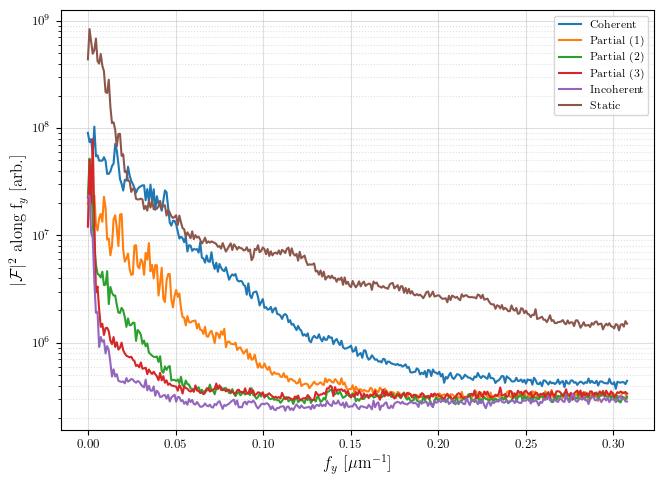

In [9]:
fig, ax = plt.subplots(figsize=(TEXTWIDTH, 5))

labels = [
    'Coherent',
    'Partial (1)',
    'Partial (2)',
    'Partial (3)',
    'Incoherent',
    'Static'
]

for i in range(len(power_1D)):
    ax.plot(fy_positive,
        power_1D[i],
        label=labels[i]
    )

ax.set_xlabel(r"$f_y$ [$\mu\mathrm{m}^{-1}$]")
ax.set_ylabel("$|\mathcal{F}|^2$ along f$_y$ [arb.]")

ax.set_yscale("log")

ax.legend()



ax.grid(
    True,
    which="major",
    alpha=0.4
)

ax.grid(
    True,
    which="minor",
    alpha=0.4,
    linestyle=":"
)

plt.tight_layout()
plt.show()

## 6. Spatial-frequency range

The spatial-frequency range used for the quantitative analysis is defined by the experimentally relevant fringe spacings.

The minimum spatial frequency is set by the largest observed fringe spacing. From the real-space images, the largest characteristic fringe separation is approximately $70~\mu\mathrm{m}$, corresponding to

$$
f_{\min}
=
\frac{1}{\Lambda_{\max}}
\approx
\frac{1}{70~\mu\mathrm{m}}
\approx
0.014~\mu\mathrm{m}^{-1}.
$$

The maximum spatial frequency is set by the Nyquist limit of the imaging system,

$$
f_{\max}
=
f_{\mathrm{Nyq}}
=
\frac{1}{2d_y},
$$

where $d_y$ is the object-plane pixel size. For $d_y \approx 1.62~\mu\mathrm{m}$,

$$
f_{\max}
\approx
0.309~\mu\mathrm{m}^{-1}.
$$

The Fourier-power analysis is therefore performed over the range

$$
0.014 \leq f_y \leq 0.309~\mu\mathrm{m}^{-1}.
$$

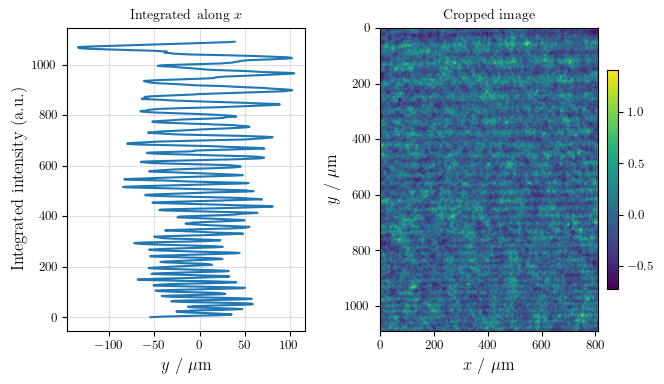

In [10]:

img_index = 0                                                                                       # Selecting the fully coherent image

img = Normalised_images[img_index]                                                                  # Select the image corresponding to the chosen index

profile_y = np.sum(img, axis=1)                                                                     # Integrate along x to obtain a 1D profile as a function of y (real space)


dx = PxSz / Mag                                                                                     # Obect plane pixel size in x
dy = PxSz / Mag                                                                                     # Obect plane pixel size in y

ny, nx = img.shape                                                                                  # Number of pixels in y and x directions

x = np.arange(nx) * dx                                                                              # Physical x coordinates in the object plane
y = np.arange(ny) * dy                                                                              # Physical y coordinates in the object plane


fig, axes = plt.subplots(1, 2,figsize=(TEXTWIDTH, 4) )                                              # plot

# Fig (a) Integrated profile (along x)
axes[0].plot(np.flip(profile_y),y)                                                                  # plotting the integrated profile along x

axes[0].set_xlabel(r"$y$ / $\mu$m")                                                                 # Setting x label
axes[0].set_ylabel("Integrated intensity (a.u.)")                                                   # Setting y label
axes[0].set_title(r"Integrated along $x$")                                                          # Setting title for the integrated profile plot

axes[0].grid(True,which="major", alpha=0.4)                                                         # Grid Major
axes[0].grid( True,which="minor",alpha=0.4,linestyle=":")                                           # Grid Minor


# (b) Cropped image
im = axes[1].imshow(img,extent=[x[0], x[-1], y[-1], y[0]],aspect='auto')                            # Display the cropped image

axes[1].set_xlabel(r"$x$ / $\mu$m")                                                                 # Setting x label for the cropped image
axes[1].set_ylabel(r"$y$ / $\mu$m")                                                                 # Setting y label for the cropped image
axes[1].set_title("Cropped image")

fig.colorbar(im,ax=axes[1],fraction=0.046,pad=0.04)                                                 # Adding colorbar for the cropped image


plt.tight_layout()                                                                                  # Adjust subplots to fit into figure area.
plt.show()                                                                                          # Display the figure



First peak:  64.80 um
Second peak: 124.74 um
Fringe spacing: 59.94 um


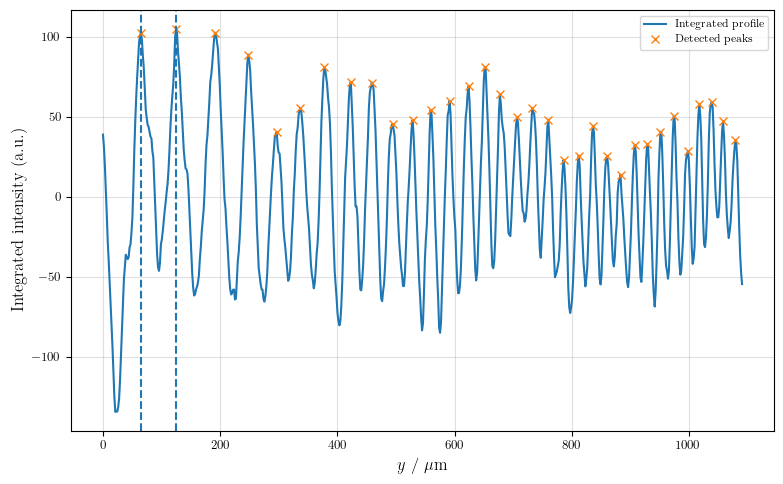

Minimum fringe spacing: 19.44 um
Maximum fringe spacing: 66.42 um
Minimum spatial frequency: 0.0151 um^-1
Maximum spatial frequency: 0.0514 um^-1


In [11]:
peaks, properties = find_peaks(profile_y, prominence=0.05 * np.max(profile_y))                      # Find significant peaks in the real-space integrated profile

peak_1 = peaks[0]                                                                                   # Index of the first detected peak
peak_2 = peaks[1]                                                                                   # Index of the second detected peak

y_peak_1 = y[peak_1]                                                                                # Convert first peak position to micrometres
y_peak_2 = y[peak_2]                                                                                # Convert second peak position to micrometres

max_fringe_spacing = np.abs(y_peak_2 - y_peak_1)                                                    # Calculate spacing between the first two detected peaks

print(f"First peak:  {y_peak_1:.2f} um")                                                            # Print position of the first peak
print(f"Second peak: {y_peak_2:.2f} um")                                                            # Print position of the second peak
print(f"Fringe spacing: {max_fringe_spacing:.2f} um")                                               # Print spacing between the first two peaks


fig, ax = plt.subplots(figsize=(8, 5))                                                              # Create figure for visualising the detected peaks

ax.plot(y, profile_y, label="Integrated profile")                                                   # Plot the integrated real-space intensity profile

ax.plot(y[peaks], profile_y[peaks], "x", label="Detected peaks")                                    # Mark all detected peaks on the profile

ax.axvline(y_peak_1, linestyle="--")                                                                # Mark position of the first detected peak
ax.axvline(y_peak_2, linestyle="--")                                                                # Mark position of the second detected peak

ax.set_xlabel(r"$y$ / $\mu$m")                                                                      # Set x-axis label
ax.set_ylabel("Integrated intensity (a.u.)")                                                        # Set y-axis label

ax.legend()                                                                                         # Add legend

ax.grid(True, which="major", alpha=0.4)                                                             # Grid Major for the peak detection plot
ax.grid(True, which="minor", alpha=0.4, linestyle=":")                                              # Grid Minor for the peak detection plot

plt.tight_layout()                                                                                  # Adjust figure layout
plt.show()                                                                                          # Display the figure


fringe_spacings = np.diff(y[peaks])                                                                 # Calculate spacings between neighbouring detected peaks

min_spacing = np.min(fringe_spacings)                                                               # Minimum detected fringe spacing
max_spacing = np.max(fringe_spacings)                                                               # Maximum detected fringe spacing

f_max = 1 / min_spacing                                                                             # Maximum spatial frequency corresponding to the minimum fringe spacing
f_min = 1 / max_spacing                                                                             # Minimum spatial frequency corresponding to the maximum fringe spacing

print(f"Minimum fringe spacing: {min_spacing:.2f} um")                                              # Print minimum fringe spacing
print(f"Maximum fringe spacing: {max_spacing:.2f} um")                                              # Print maximum fringe spacing

print(f"Minimum spatial frequency: {f_min:.4f} um^-1")                                              # Print minimum spatial frequency
print(f"Maximum spatial frequency: {f_max:.4f} um^-1")                                              # Print maximum spatial frequency

## 6. Integrated Fourier power

To quantify the strength of the coherence-induced fringes, the one-dimensional Fourier-power spectrum is integrated over the spatial-frequency range associated with the observed fringe structure.

The lower frequency limit is set by the largest measured fringe spacing, corresponding to approximately

$$
f_{\min} = 0.014~\mu\mathrm{m}^{-1}.
$$

The upper frequency limit is set by the Nyquist frequency of the imaging system,

$$
f_{\max} = 0.309~\mu\mathrm{m}^{-1}.
$$

The Fourier power contained within this band is therefore calculated as

$$
P_{\mathrm{band}}
=
\sum_{f_{\min} \leq f_y \leq f_{\max}}
P_{\mathrm{1D}}(f_y).
$$

The integrated power for each image is then normalised to the fully coherent image,

$$
P_{\mathrm{norm},i}
=
\frac{P_{\mathrm{band},i}}
{P_{\mathrm{band,coh}}},
$$

such that the fully coherent image has a normalised power of 1. Values below 1 therefore indicate suppression of Fourier power within the spatial-frequency band associated with the fringes.

In [12]:
frequency_mask = (fy_positive >= f_min) & (fy_positive <= f_max)                                     # Select the spatial-frequency range associated with the fringes

band_power = []                                                                                       # Empty list for storing the integrated Fourier power in the selected band

for i in range(len(power_1D)):

    integrated_power = np.sum(power_1D[i][frequency_mask])                                           # Integrate the 1D Fourier power only within the selected frequency band

    band_power.append(integrated_power)                                                               # Store one integrated power value for each illumination condition

band_power = np.asarray(band_power)                                                                   # Convert integrated power values to a NumPy array

normalised_power = band_power / band_power[0]                                                        # Normalise integrated Fourier power to the fully coherent image

print("Integrated Fourier power:", band_power)                                                        # Print the band-integrated Fourier power
print("Normalised Fourier power:", normalised_power)                                                  # Print the normalised band-integrated Fourier power

Integrated Fourier power: [1.08252278e+09 2.36111024e+08 4.41927987e+07 2.41009203e+07
 1.54246864e+07 1.16867942e+09]
Normalised Fourier power: [1.         0.21811183 0.0408239  0.02226366 0.01424883 1.07958876]


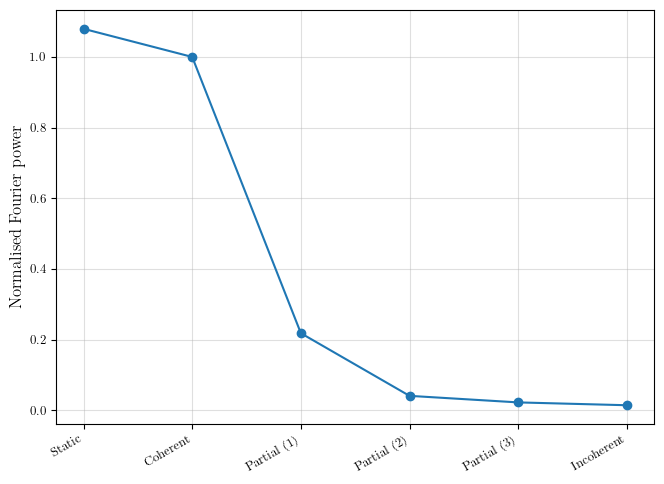

In [13]:
plot_order = [5, 0, 1, 2, 3, 4]                                                                     # Plot Static first, followed by the remaining illumination conditions

labels = [
    'Static',
    'Coherent',
    'Partial (1)',
    'Partial (2)',
    'Partial (3)',
    'Incoherent'
]

normalised_power_plot = normalised_power[plot_order]                                                 # Reorder the band-integrated Fourier power values for plotting


fig, ax = plt.subplots(figsize=(TEXTWIDTH, 5))                                                       # Create figure for the normalised integrated Fourier power

ax.plot(
    np.arange(len(normalised_power_plot)),
    normalised_power_plot,
    'o-'
)                                                                                                  # Plot one band-integrated Fourier power value for each illumination condition

ax.set_xticks(np.arange(len(labels)))                                                                # Set x-axis tick positions
ax.set_xticklabels(labels, rotation=30, ha='right')                                                 # Label each illumination condition

ax.set_ylabel("Normalised Fourier power")                                                            # Set y-axis label

ax.grid(True, which="major", alpha=0.4)                                                              # Grid Major
ax.grid(True, which="minor", alpha=0.4, linestyle=":")                                              # Grid Minor

plt.tight_layout()                                                                                   # Adjust figure layout
plt.show()                                                                                           # Display the figure

## 7. Band-limited RMS fringe contrast

As a complementary real-space measure of the fringe amplitude, the Fourier spectrum is filtered to retain only the spatial-frequency components within the same fringe-frequency band used for the integrated-power analysis.

The filtered spectrum is then transformed back into real space, giving a band-limited image containing only the spatial structure associated with the coherence-induced fringes.

The RMS contrast is calculated as

$$
C_{\mathrm{RMS}}
=
\sqrt{
\frac{1}{N}
\sum_{j=1}^{N}
\left(
I_j-\overline{I}
\right)^2
},
$$

where $I_j$ is the value of the $j$th pixel in the band-limited image, $\overline{I}$ is the mean pixel value, and $N$ is the total number of pixels.

For an ideal sinusoidal fringe pattern, the RMS contrast is directly related to the conventional fringe visibility by

$$
V = \sqrt{2}\,C_{\mathrm{RMS}}.
$$

The RMS contrast is used here because the experimentally observed fringe patterns are not perfectly sinusoidal and contain multiple spatial-frequency components. It therefore provides a more robust measure of the overall fringe amplitude than relying only on the maximum and minimum image values.

As for the Fourier-power analysis, the RMS contrast is normalised to the fully coherent image.

RMS fringe contrast: [0.13807137 0.0644827  0.02789722 0.02060165 0.01648137 0.14346065]
Normalised RMS contrast: [1.         0.46702444 0.20204924 0.14921012 0.11936848 1.03903261]


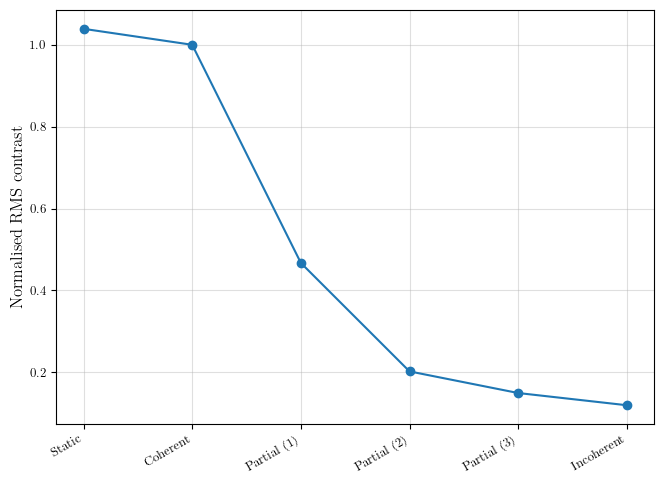

In [14]:


dy = PxSz / Mag                                                                                     # Object-plane pixel size [um]

ny, nx = windowedImgs[0].shape                                                                      # Number of pixels in the y and x directions

fy = np.fft.fftshift(np.fft.fftfreq(ny, d=dy))                                                      # Spatial-frequency axis in y [um^-1]

frequency_mask_y = (np.abs(fy) >= f_min) & (np.abs(fy) <= f_max)                                    # Select positive and negative fy components within the fringe band

contrast_RMS = []                                                                                   # Empty list for storing the RMS fringe contrast
band_limited_images = []                                                                            # Empty list for storing the reconstructed band-limited images

for img in windowedImgs:

    fft = np.fft.fft2(img)                                                                          # Calculate the 2D Fourier transform
    fft_shift = np.fft.fftshift(fft)                                                                # Shift zero spatial frequency to the centre

    mask_2D = frequency_mask_y[:, None]                                                             # Expand the fy mask across the full fx direction
    fft_filtered = fft_shift * mask_2D                                                              # Retain only Fourier components within the selected fy band

    img_filtered = np.fft.ifft2(np.fft.ifftshift(fft_filtered)).real                                # Transform the band-limited spectrum back into real space

    band_limited_images.append(img_filtered)                                                        # Store the reconstructed band-limited image

    contrast = np.sqrt(np.mean((img_filtered - np.mean(img_filtered))**2))                          # Calculate the RMS contrast of the band-limited image
    contrast_RMS.append(contrast)                                                                   # Store the RMS contrast

contrast_RMS = np.asarray(contrast_RMS)                                                             # Convert RMS contrast values to a NumPy array
band_limited_images = np.asarray(band_limited_images)                                               # Convert reconstructed images to a NumPy array

normalised_contrast = contrast_RMS / contrast_RMS[0]                                                # Normalise RMS contrast to the fully coherent image



print("RMS fringe contrast:", contrast_RMS)                                                         # Print the RMS contrast values
print("Normalised RMS contrast:", normalised_contrast)                                              # Print the normalised RMS contrast values

plot_order = [5, 0, 1, 2, 3, 4]                                                                     # Plot Static first, followed by decreasing coherence

labels = [
    'Static',
    'Coherent',
    'Partial (1)',
    'Partial (2)',
    'Partial (3)',
    'Incoherent'
]

normalised_contrast_plot = normalised_contrast[plot_order]                                          # Reorder the RMS contrast values for plotting

fig, ax = plt.subplots(figsize=(TEXTWIDTH, 5))                                                      # Create figure for the normalised RMS fringe contrast

ax.plot(np.arange(len(normalised_contrast_plot)),normalised_contrast_plot,'o-')                     # Plot the normalised RMS fringe contrast

ax.set_xticks(np.arange(len(labels)))                                                               # Set x-axis tick positions
ax.set_xticklabels(labels, rotation=30, ha='right')                                                 # Label each illumination condition

ax.set_ylabel("Normalised RMS contrast")                                                            # Set y-axis label

ax.grid(True, which="major", alpha=0.4)                                                             # Grid Major
ax.grid(True, which="minor", alpha=0.4, linestyle=":")                                              # Grid Minor

plt.tight_layout()                                                                                  # Adjust figure layout
plt.show()                                                                                          # Display the figure

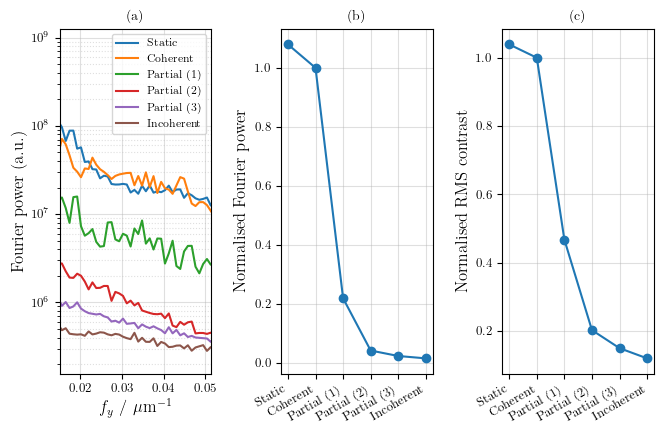

In [17]:
plot_order = [5, 0, 1, 2, 3, 4]                                                                     # Plot Static first, followed by the remaining illumination conditions

labels = [
    'Static',
    'Coherent',
    'Partial (1)',
    'Partial (2)',
    'Partial (3)',
    'Incoherent'
]                                                                                                   # Labels for the different illumination conditions

power_1D_plot = power_1D[plot_order]                                                                # Reorder the 1D Fourier-power spectra for plotting
normalised_power_plot = normalised_power[plot_order]                                                # Reorder the normalised integrated Fourier power
normalised_contrast_plot = normalised_contrast[plot_order]                                          # Reorder the normalised RMS contrast

x = np.arange(len(labels))                                                                          # Define x positions for the categorical plots

fig, axes = plt.subplots(1, 3, figsize=(TEXTWIDTH, 4.5))                                            # Create a three-panel figure

# ------------------------------------------------------------------
# (a) Overlaid 1D Fourier-power spectra
# ------------------------------------------------------------------

for i in range(len(power_1D_plot)):

    axes[0].plot(
        fy_positive,
        power_1D_plot[i],
        label=labels[i]
    )                                                                                               # Plot the 1D Fourier-power spectrum for each illumination condition

# axes[0].axvspan(
#     f_min,
#     f_max,
#     alpha=0.2
# )                                                                                                   # Shade the spatial-frequency band used for the integrated-power analysis

axes[0].set_xlabel(r"$f_y$ / $\mu\mathrm{m}^{-1}$")                                                 # Set x-axis label
axes[0].set_ylabel("Fourier power (a.u.)")                                                          # Set y-axis label
axes[0].set_yscale("log")                                                                           # Use logarithmic scale for the Fourier power
axes[0].set_title("(a)")                                                                            # Panel label
axes[0].set_xlim(f_min, f_max)                                                 # Set x-axis limits for the Fourier power plot

axes[0].legend(fontsize=8)                                                                          # Add legend to panel (a)

axes[0].grid(True, which="major", alpha=0.4)                                                        # Grid Major
axes[0].grid(True, which="minor", alpha=0.4, linestyle=":")                                         # Grid Minor

# ------------------------------------------------------------------
# (b) Normalised integrated Fourier power
# ------------------------------------------------------------------

axes[1].plot(
    x,
    normalised_power_plot,
    'o-'
)                                                                                                   # Plot the integrated Fourier power normalised to the coherent image

axes[1].set_xticks(x)                                                                               # Set x-axis tick positions
axes[1].set_xticklabels(labels, rotation=30, ha='right')                                            # Label each illumination condition
axes[1].set_ylabel("Normalised Fourier power")                                                      # Set y-axis label
axes[1].set_title("(b)")                                                                            # Panel label

axes[1].grid(True, which="major", alpha=0.4)                                                        # Grid Major
axes[1].grid(True, which="minor", alpha=0.4, linestyle=":")                                         # Grid Minor

# ------------------------------------------------------------------
# (c) Normalised band-limited RMS contrast
# ------------------------------------------------------------------

axes[2].plot(
    x,
    normalised_contrast_plot,
    'o-'
)                                                                                                   # Plot the RMS fringe contrast normalised to the coherent image

axes[2].set_xticks(x)                                                                               # Set x-axis tick positions
axes[2].set_xticklabels(labels, rotation=30, ha='right')                                            # Label each illumination condition
axes[2].set_ylabel("Normalised RMS contrast")                                                       # Set y-axis label
axes[2].set_title("(c)")                                                                            # Panel label

axes[2].grid(True, which="major", alpha=0.4)                                                        # Grid Major
axes[2].grid(True, which="minor", alpha=0.4, linestyle=":")                                         # Grid Minor

plt.tight_layout()                                                                                  # Adjust subplot spacing to fit neatly within the figure
plt.show()                                                                                          # Display the figure